In [6]:
import torch

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    device = torch.device('cuda')
else:
    print("⚠️ GPU YOK! Runtime → T4 GPU yap")
    device = torch.device('cpu')

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
Memory: 15.6 GB


In [7]:
from getpass import getpass

github_token = getpass('GitHub token: ')
github_user = 'iremcesur'
repo_name = 'CENG467_Midterm_310201051'

!git clone https://{github_token}@github.com/{github_user}/{repo_name}.git
%cd {repo_name}

!git config user.email "iremcesur310201051@gmail.com"
!git config user.name "iremcesur"
!git config pull.rebase false

GitHub token: ··········
Cloning into 'CENG467_Midterm_310201051'...
remote: Enumerating objects: 74, done.
remote: Counting objects: 100% (74/74), done.
remote: Compressing objects: 100% (64/64), done.
remote: Total 74 (delta 20), reused 54 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (74/74), 1.93 MiB | 5.81 MiB/s, done.
Resolving deltas: 100% (20/20), done.
/content/CENG467_Midterm_310201051


In [ ]:
import random
import numpy as np
import torch
import os

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"✓ Seeds set to {SEED}")

# Transformers ve datasets kontrolü
!pip install -q transformers datasets accelerate
print("✓ Libraries ready")

✓ Seeds set to 42
✓ Libraries ready


In [ ]:
import pandas as pd
import numpy as np
from datasets import Dataset, load_dataset
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
)
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import json
import time
from tqdm.notebook import tqdm

print("✓ All imports successful")

✓ All imports successful


In [ ]:
print("Loading IMDb dataset...")
dataset = load_dataset("imdb")

train_df = pd.DataFrame(dataset['train'])
test_df = pd.DataFrame(dataset['test'])

# AYNI SEED, AYNI subset
train_subset, val_subset = train_test_split(
    train_df.sample(n=6000, random_state=SEED, replace=False),
    test_size=1000,
    stratify=train_df.sample(n=6000, random_state=SEED, replace=False)['label'],
    random_state=SEED
)
test_subset = test_df.sample(n=2000, random_state=SEED, replace=False)

train_subset = train_subset.reset_index(drop=True)
val_subset = val_subset.reset_index(drop=True)
test_subset = test_subset.reset_index(drop=True)

print(f"\nSubset sizes (must match TF-IDF/BiLSTM):")
print(f"  Train: {len(train_subset)} | {train_subset['label'].value_counts().to_dict()}")
print(f"  Val:   {len(val_subset)}  | {val_subset['label'].value_counts().to_dict()}")
print(f"  Test:  {len(test_subset)} | {test_subset['label'].value_counts().to_dict()}")

Loading IMDb dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]


Subset sizes (must match TF-IDF/BiLSTM):
  Train: 5000 | {1: 2507, 0: 2493}
  Val:   1000  | {1: 501, 0: 499}
  Test:  2000 | {0: 1040, 1: 960}


In [ ]:
MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 256  # BiLSTM ile aynı (fair comparison)

# Tokenizer'ı yükle
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

print(f"Tokenizer: {MODEL_NAME}")
print(f"Vocab size: {tokenizer.vocab_size:,}")
print(f"Max length: {MAX_LEN}")

# Test
sample = "This movie was absolutely fantastic, one of the best!"
tokens = tokenizer(sample, truncation=True, max_length=20, padding='max_length', return_tensors='pt')
print(f"\nSample tokenization:")
print(f"  Input: {sample}")
print(f"  Tokens: {tokenizer.convert_ids_to_tokens(tokens['input_ids'][0])[:15]}")
print(f"  Note: WordPiece subword tokens (## prefix = continuation)")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer: distilbert-base-uncased
Vocab size: 30,522
Max length: 256

Sample tokenization:
  Input: This movie was absolutely fantastic, one of the best!
  Tokens: ['[CLS]', 'this', 'movie', 'was', 'absolutely', 'fantastic', ',', 'one', 'of', 'the', 'best', '!', '[SEP]', '[PAD]', '[PAD]']
  Note: WordPiece subword tokens (## prefix = continuation)


In [ ]:
def prepare_dataset(df):
    """Pandas DataFrame'i HuggingFace Dataset formatına çevirir."""
    return Dataset.from_pandas(df[['text', 'label']], preserve_index=False)

train_ds = prepare_dataset(train_subset)
val_ds = prepare_dataset(val_subset)
test_ds = prepare_dataset(test_subset)

print(f"Train: {train_ds}")
print(f"\nFirst example:")
print(f"  Label: {train_ds[0]['label']}")
print(f"  Text (first 200 chars): {train_ds[0]['text'][:200]}...")

Train: Dataset({
    features: ['text', 'label'],
    num_rows: 5000
})

First example:
  Label: 1
  Text (first 200 chars): Dripping with symbolism and filled with marvelous cinematography, Extase is so much more than the erotic drama we've all come to expect. This is almost a silent film, with what dialogue there is in Ge...


In [ ]:
def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        truncation=True,
        max_length=MAX_LEN,
        padding=False,  # Dynamic padding (collator ile)
    )

print("Tokenizing datasets...")
train_ds = train_ds.map(tokenize_function, batched=True, remove_columns=['text'])
val_ds = val_ds.map(tokenize_function, batched=True, remove_columns=['text'])
test_ds = test_ds.map(tokenize_function, batched=True, remove_columns=['text'])

# Format for PyTorch
train_ds.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
val_ds.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
test_ds.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])

print(f"\n✓ Tokenization complete")
print(f"Train shape: {train_ds[0]['input_ids'].shape}")
print(f"Sample tokens (first 20): {train_ds[0]['input_ids'][:20]}")

Tokenizing datasets...


Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]


✓ Tokenization complete
Train shape: torch.Size([256])
Sample tokens (first 20): tensor([  101, 14309,  2007, 22050,  1998,  3561,  2007, 28851, 16434,  1010,
         4654, 18260,  2003,  2061,  2172,  2062,  2084,  1996, 14253,  3689])


In [ ]:
# Pre-trained DistilBERT'i sınıflandırma head'i ile yükle
model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,  # Binary classification
    id2label={0: 'NEGATIVE', 1: 'POSITIVE'},
    label2id={'NEGATIVE': 0, 'POSITIVE': 1},
)

# Parametreleri say
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model: {MODEL_NAME}")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"\nNote: All parameters are trainable (full fine-tuning).")
print(f"Compare to BiLSTM (235K trainable) — DistilBERT has ~280x more capacity.")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model: distilbert-base-uncased
Total parameters: 66,955,010
Trainable parameters: 66,955,010

Note: All parameters are trainable (full fine-tuning).
Compare to BiLSTM (235K trainable) — DistilBERT has ~280x more capacity.


In [ ]:
def compute_metrics(eval_pred):
    """Trainer için metric hesaplama fonksiyonu."""
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, predictions),
        'f1_macro': f1_score(labels, predictions, average='macro'),
    }

# Output directory
output_dir = './distilbert_output'

# Training arguments
training_args = TrainingArguments(
    output_dir=output_dir,
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=94,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    greater_is_better=True,
    logging_steps=50,
    report_to='none',
    seed=SEED,
    fp16=True,
    save_total_limit=1,
)

# Data collator (dynamic padding)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print("✓ Trainer configured")
print(f"  Epochs: {training_args.num_train_epochs}")
print(f"  Batch size: {training_args.per_device_train_batch_size}")
print(f"  Learning rate: {training_args.learning_rate}")
print(f"  Warmup steps: {training_args.warmup_steps}")
print(f"  fp16 (mixed precision): {training_args.fp16}")

✓ Trainer configured
  Epochs: 3
  Batch size: 16
  Learning rate: 2e-05
  Warmup steps: 94
  fp16 (mixed precision): True


In [ ]:
print("=" * 70)
print("Starting DistilBERT fine-tuning...")
print("=" * 70)

start_time = time.time()
train_result = trainer.train()
total_time = time.time() - start_time

print("\n" + "=" * 70)
print(f"Training complete in {total_time:.1f}s ({total_time/60:.1f} min)")
print(f"Final train metrics: {train_result.metrics}")

# History'yi kaydet (raporda kullanmak için)
log_history = trainer.state.log_history
train_history = {
    'epoch': [],
    'eval_loss': [],
    'eval_accuracy': [],
    'eval_f1_macro': [],
}
for log in log_history:
    if 'eval_loss' in log:
        train_history['epoch'].append(log['epoch'])
        train_history['eval_loss'].append(log['eval_loss'])
        train_history['eval_accuracy'].append(log['eval_accuracy'])
        train_history['eval_f1_macro'].append(log['eval_f1_macro'])

# Train loss ayrı topla (daha sık logged)
train_losses = [(log['step'], log['loss']) for log in log_history
                if 'loss' in log and 'eval_loss' not in log]
train_history['train_loss_steps'] = train_losses

print(f"\nValidation metrics across epochs:")
for e, l, a, f in zip(
    train_history['epoch'], train_history['eval_loss'],
    train_history['eval_accuracy'], train_history['eval_f1_macro']
):
    print(f"  Epoch {e:.1f} | Val Loss: {l:.4f} | Val Acc: {a:.4f} | Val F1: {f:.4f}")

Starting DistilBERT fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.293792,0.322324,0.860000,0.859229
2,0.236533,0.309378,0.888000,0.887885
3,0.109965,0.346380,0.897000,0.896963


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



Training complete in 137.7s (2.3 min)
Final train metrics: {'train_runtime': 137.0269, 'train_samples_per_second': 109.468, 'train_steps_per_second': 6.853, 'total_flos': 993505489920000.0, 'train_loss': 0.25388831680955976, 'epoch': 3.0}

Validation metrics across epochs:
  Epoch 1.0 | Val Loss: 0.3223 | Val Acc: 0.8600 | Val F1: 0.8592
  Epoch 2.0 | Val Loss: 0.3094 | Val Acc: 0.8880 | Val F1: 0.8879
  Epoch 3.0 | Val Loss: 0.3464 | Val Acc: 0.8970 | Val F1: 0.8970


In [ ]:
print("=" * 70)
print("DistilBERT — FINAL TEST EVALUATION")
print("=" * 70)

# Test set üzerinde tahmin
test_results = trainer.predict(test_ds)

test_preds = np.argmax(test_results.predictions, axis=-1)
test_labels = test_results.label_ids
test_probs = torch.softmax(torch.tensor(test_results.predictions), dim=-1).numpy()
test_pos_probs = test_probs[:, 1]

# Metrikler
test_acc = accuracy_score(test_labels, test_preds)
test_f1 = f1_score(test_labels, test_preds, average='macro')

print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Macro-F1: {test_f1:.4f}")
print(f"Test Loss: {test_results.metrics['test_loss']:.4f}")
print()
print("Detailed Classification Report:")
print(classification_report(test_labels, test_preds,
                            target_names=['Negative', 'Positive'],
                            digits=4))

DistilBERT — FINAL TEST EVALUATION



Test Accuracy: 0.9030
Test Macro-F1: 0.9028
Test Loss: 0.3168

Detailed Classification Report:
              precision    recall  f1-score   support

    Negative     0.9036    0.9106    0.9071      1040
    Positive     0.9023    0.8948    0.8985       960

    accuracy                         0.9030      2000
   macro avg     0.9030    0.9027    0.9028      2000
weighted avg     0.9030    0.9030    0.9030      2000



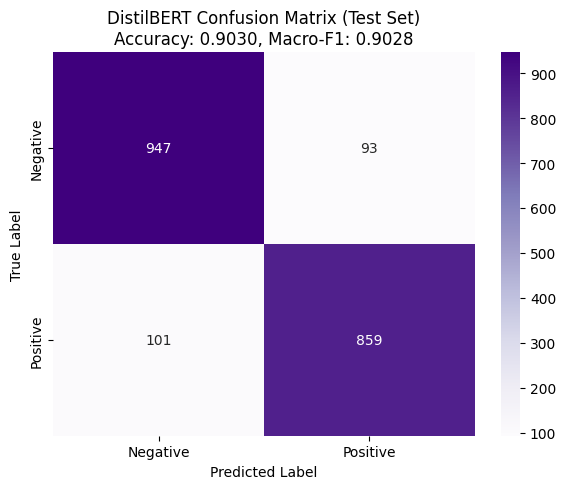


Breakdown:
  TN: 947, FP: 93, FN: 101, TP: 859


In [ ]:
cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title(f'DistilBERT Confusion Matrix (Test Set)\nAccuracy: {test_acc:.4f}, Macro-F1: {test_f1:.4f}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()

plt.savefig('q1_classification/results/distilbert_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nBreakdown:")
print(f"  TN: {cm[0,0]}, FP: {cm[0,1]}, FN: {cm[1,0]}, TP: {cm[1,1]}")

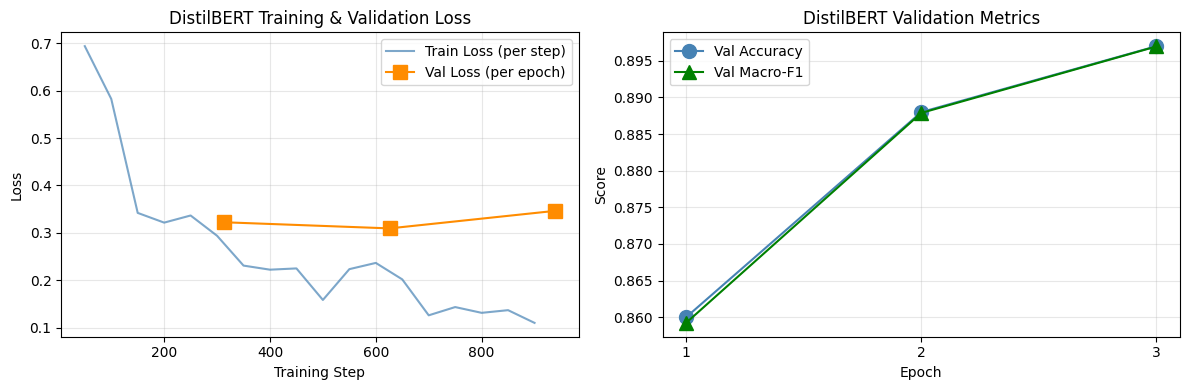

✓ Training curves saved


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Train loss steps (her 50 step)
steps, losses = zip(*train_history['train_loss_steps'])

axes[0].plot(steps, losses, '-', label='Train Loss (per step)', color='steelblue', alpha=0.7)
# Val loss epoch'ta (step'e dönüştür: epoch * 313)
val_steps = [int(e * 313) for e in train_history['epoch']]
axes[0].plot(val_steps, train_history['eval_loss'], 's-', label='Val Loss (per epoch)',
             color='darkorange', markersize=10)
axes[0].set_xlabel('Training Step')
axes[0].set_ylabel('Loss')
axes[0].set_title('DistilBERT Training & Validation Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(train_history['epoch'], train_history['eval_accuracy'], 'o-',
             label='Val Accuracy', color='steelblue', markersize=10)
axes[1].plot(train_history['epoch'], train_history['eval_f1_macro'], '^-',
             label='Val Macro-F1', color='green', markersize=10)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].set_title('DistilBERT Validation Metrics')
axes[1].legend()
axes[1].set_xticks(train_history['epoch'])
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('q1_classification/results/distilbert_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Training curves saved")

In [ ]:
# Test predictions kaydet
test_subset_with_preds = test_subset.copy()
test_subset_with_preds['distilbert_pred'] = test_preds
test_subset_with_preds['distilbert_correct'] = (test_preds == test_labels)
test_subset_with_preds['distilbert_pos_prob'] = test_pos_probs

test_subset_with_preds.to_csv(
    'q1_classification/results/test_predictions_distilbert.csv', index=False
)
print("✓ Test predictions saved")

# JSON sonuçlar
results = {
    'model': 'DistilBERT (distilbert-base-uncased) fine-tuned',
    'config': {
        'model_name': MODEL_NAME,
        'max_seq_length': MAX_LEN,
        'num_train_epochs': 3,
        'batch_size': 16,
        'learning_rate': 2e-5,
        'weight_decay': 0.01,
        'warmup_steps': 94,
        'fp16': True,
        'early_stopping_patience': 2,
    },
    'subset_sizes': {'train': 5000, 'val': 1000, 'test': 2000},
    'random_seed': SEED,
    'training_time_seconds': total_time,
    'val_history': {
        'epoch': train_history['epoch'],
        'val_loss': [float(x) for x in train_history['eval_loss']],
        'val_accuracy': [float(x) for x in train_history['eval_accuracy']],
        'val_f1_macro': [float(x) for x in train_history['eval_f1_macro']],
    },
    'test_metrics': {
        'accuracy': float(test_acc),
        'macro_f1': float(test_f1),
        'loss': float(test_results.metrics['test_loss']),
        'confusion_matrix': cm.tolist(),
    }
}

with open('q1_classification/results/distilbert_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("✓ Results JSON saved")

# Git push
!git pull origin main --no-edit
!git add q1_classification/
!git commit -m "Q1: DistilBERT fine-tuned (test acc/f1 added)"
!git push origin main

✓ Test predictions saved
✓ Results JSON saved
From https://github.com/iremcesur/CENG467_Midterm_310201051
 * branch            main       -> FETCH_HEAD
Already up to date.
[main 6d42240] Q1: DistilBERT fine-tuned (test acc/f1 added)
 4 files changed, 2059 insertions(+)
 create mode 100644 q1_classification/results/distilbert_confusion_matrix.png
 create mode 100644 q1_classification/results/distilbert_results.json
 create mode 100644 q1_classification/results/distilbert_training_curves.png
 create mode 100644 q1_classification/results/test_predictions_distilbert.csv
Enumerating objects: 11, done.
Counting objects: 100% (11/11), done.
Delta compression using up to 2 threads
Compressing objects: 100% (8/8), done.
Writing objects: 100% (8/8), 1.14 MiB | 1.25 MiB/s, done.
Total 8 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/iremcesur/CENG467_Midterm_310201051.git
   5a3eeaf..6d42240  main -> main


In [ ]:
# 3 modelin tahminlerini birleştir
import pandas as pd

# CSV'leri yükle (her notebook bunları kaydetmişti)
tfidf_df = pd.read_csv('q1_classification/results/test_predictions_tfidf.csv')
bilstm_df = pd.read_csv('q1_classification/results/test_predictions_bilstm.csv')
bert_df = pd.read_csv('q1_classification/results/test_predictions_distilbert.csv')

# Sanity check: aynı satır sayısı, aynı label'lar
assert len(tfidf_df) == len(bilstm_df) == len(bert_df) == 2000
assert (tfidf_df['label'] == bilstm_df['label']).all()
assert (tfidf_df['label'] == bert_df['label']).all()
print("✓ All three test sets aligned")

# Birleştirilmiş DataFrame
combined = pd.DataFrame({
    'text': tfidf_df['text'],
    'true_label': tfidf_df['label'],
    'tfidf_pred': tfidf_df['tfidf_pred'],
    'tfidf_prob': tfidf_df['tfidf_pos_prob'],
    'bilstm_pred': bilstm_df['bilstm_pred'],
    'bilstm_prob': bilstm_df['bilstm_pos_prob'],
    'bert_pred': bert_df['distilbert_pred'],
    'bert_prob': bert_df['distilbert_pos_prob'],
})

# Her model için correctness flag
combined['tfidf_correct'] = combined['tfidf_pred'] == combined['true_label']
combined['bilstm_correct'] = combined['bilstm_pred'] == combined['true_label']
combined['bert_correct'] = combined['bert_pred'] == combined['true_label']

# Kaç tane "her üç model de yanlış" var?
all_wrong = combined[~combined['tfidf_correct'] & ~combined['bilstm_correct'] & ~combined['bert_correct']]
all_correct = combined[combined['tfidf_correct'] & combined['bilstm_correct'] & combined['bert_correct']]
only_bert_correct = combined[~combined['tfidf_correct'] & ~combined['bilstm_correct'] & combined['bert_correct']]
only_bert_wrong = combined[combined['tfidf_correct'] & combined['bilstm_correct'] & ~combined['bert_correct']]

print(f"\n=== Cross-model error patterns (n=2000 test examples) ===")
print(f"All three models correct:        {len(all_correct)} ({len(all_correct)/2000*100:.1f}%)")
print(f"All three models WRONG:          {len(all_wrong)} ({len(all_wrong)/2000*100:.1f}%)")
print(f"Only BERT correct (others wrong): {len(only_bert_correct)} ({len(only_bert_correct)/2000*100:.1f}%)")
print(f"Only BERT wrong (others correct): {len(only_bert_wrong)} ({len(only_bert_wrong)/2000*100:.1f}%)")

# CSV olarak kaydet
combined.to_csv('q1_classification/results/cross_model_predictions.csv', index=False)
print("\n✓ Saved cross_model_predictions.csv")

✓ All three test sets aligned

=== Cross-model error patterns (n=2000 test examples) ===
All three models correct:        1513 (75.6%)
All three models WRONG:          71 (3.5%)
Only BERT correct (others wrong): 55 (2.8%)
Only BERT wrong (others correct): 55 (2.8%)

✓ Saved cross_model_predictions.csv


In [ ]:
# Belirli kategorilerden örnekler seç
def show_example(row, idx):
    text = row['text'][:300]
    label_str = "Positive" if row['true_label'] == 1 else "Negative"
    print(f"\n--- Example {idx} ---")
    print(f"True: {label_str}")
    print(f"  TF-IDF:     pred={['Neg','Pos'][row['tfidf_pred']]} (prob_pos={row['tfidf_prob']:.3f}) {'✓' if row['tfidf_correct'] else '✗'}")
    print(f"  BiLSTM:     pred={['Neg','Pos'][row['bilstm_pred']]} (prob_pos={row['bilstm_prob']:.3f}) {'✓' if row['bilstm_correct'] else '✗'}")
    print(f"  DistilBERT: pred={['Neg','Pos'][row['bert_pred']]} (prob_pos={row['bert_prob']:.3f}) {'✓' if row['bert_correct'] else '✗'}")
    print(f"Text: {text}...")

print("=" * 70)
print("CATEGORY 1: All three models WRONG (genuinely hard examples)")
print("=" * 70)
# En "emin yanlış" olanları seç (BERT prob_pos en uçtaki yanlışlar)
all_wrong_sorted = all_wrong.copy()
all_wrong_sorted['confidence'] = abs(all_wrong_sorted['bert_prob'] - 0.5)
all_wrong_sorted = all_wrong_sorted.sort_values('confidence', ascending=False)
for i, (_, row) in enumerate(all_wrong_sorted.head(2).iterrows(), 1):
    show_example(row, i)

print("\n" + "=" * 70)
print("CATEGORY 2: Only BERT correct (BERT's contextual advantage)")
print("=" * 70)
# BERT'in en güvenli doğru tahminleri (others wrong)
only_bert_correct_sorted = only_bert_correct.copy()
only_bert_correct_sorted['bert_confidence'] = abs(only_bert_correct_sorted['bert_prob'] - 0.5)
only_bert_correct_sorted = only_bert_correct_sorted.sort_values('bert_confidence', ascending=False)
for i, (_, row) in enumerate(only_bert_correct_sorted.head(2).iterrows(), 3):
    show_example(row, i)

print("\n" + "=" * 70)
print("CATEGORY 3: BERT wrong but TF-IDF/BiLSTM correct (BERT's failure mode)")
print("=" * 70)
if len(only_bert_wrong) > 0:
    only_bert_wrong_sorted = only_bert_wrong.copy()
    only_bert_wrong_sorted['bert_confidence'] = abs(only_bert_wrong_sorted['bert_prob'] - 0.5)
    only_bert_wrong_sorted = only_bert_wrong_sorted.sort_values('bert_confidence', ascending=False)
    for i, (_, row) in enumerate(only_bert_wrong_sorted.head(1).iterrows(), 5):
        show_example(row, i)
else:
    print("(none — BERT did not miss any that both others got right)")

CATEGORY 1: All three models WRONG (genuinely hard examples)

--- Example 1 ---
True: Negative
  TF-IDF:     pred=Pos (prob_pos=0.758) ✗
  BiLSTM:     pred=Pos (prob_pos=0.995) ✗
  DistilBERT: pred=Pos (prob_pos=0.996) ✗
Text: 'Ernest Saves Christmas' is comedian Ernest's Christmas special film. In this film, Ernest has to find a successor to Santa Claus in order for Christmas to continue. Along the way, he meets a young girl who is a thief and who ends up stealing something very important of Santa's (I won't tell you wha...

--- Example 2 ---
True: Negative
  TF-IDF:     pred=Pos (prob_pos=0.516) ✗
  BiLSTM:     pred=Pos (prob_pos=0.865) ✗
  DistilBERT: pred=Pos (prob_pos=0.995) ✗
Text: The Adventures of Sebastian Cole is about a boy named Sebastian (Adrian Grenier) who fancies himself becoming a writer at some point, given he actually puts effort into it. This movie is presumably the years where he gets his material for writing, the adventure years, hence the title and the previou...

In [4]:
from google.colab import drive
drive.mount('/content/drive')

!find /content/drive/MyDrive -name "*.ipynb" 2>/dev/null

Mounted at /content/drive
/content/drive/MyDrive/Colab Notebooks/day one.ipynb
/content/drive/MyDrive/Colab Notebooks/CENG463_HW3_GROUP03.ipynb
/content/drive/MyDrive/Colab Notebooks/statistical_data_visualization_fill_in_the_blanks_en.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled0.ipynb
/content/drive/MyDrive/Colab Notebooks/setup.ipynb
/content/drive/MyDrive/Colab Notebooks/q1_bilstm.ipynb
/content/drive/MyDrive/Colab Notebooks/q5_language_modeling.ipynb
/content/drive/MyDrive/Colab Notebooks/q3_summarization.ipynb
/content/drive/MyDrive/Colab Notebooks/q2_ner.ipynb
/content/drive/MyDrive/Colab Notebooks/q4_seq2seq_nmt.ipynb
/content/drive/MyDrive/Colab Notebooks/q1_tfidf_baseline.ipynb
/content/drive/MyDrive/Colab Notebooks/q1_distilbert.ipynb
/content/drive/MyDrive/CENG 3. YIL/CENG463/week7/ready2UseDatasetML.ipynb
/content/drive/MyDrive/CENG 3. YIL/CENG463/week7/sentimentAnalysis.ipynb
/content/drive/MyDrive/CENG 3. YIL/CENG463/week11/UnsupervisedLearningSecondPart.ipynb
/

In [8]:
import os
os.chdir('/content/CENG467_Midterm_310201051')

# Root'taki yanlış yerdeki notebook'u sil
!git rm q1_tfidf_baseline.ipynb

# Diğer tüm notebook'ları kopyala ve push et
!cp "/content/drive/MyDrive/Colab Notebooks/q1_bilstm.ipynb" q1_classification/notebooks/
!cp "/content/drive/MyDrive/Colab Notebooks/q1_distilbert.ipynb" q1_classification/notebooks/
!cp "/content/drive/MyDrive/Colab Notebooks/q2_ner.ipynb" q2_ner/
!cp "/content/drive/MyDrive/Colab Notebooks/q3_summarization.ipynb" q3_summarization/
!cp "/content/drive/MyDrive/Colab Notebooks/q4_seq2seq_nmt.ipynb" q4_translation/
!cp "/content/drive/MyDrive/Colab Notebooks/q5_language_modeling.ipynb" q5_language_modeling/

import json, glob
for path in glob.glob('**/*.ipynb', recursive=True):
    with open(path, 'r') as f:
        nb = json.load(f)
    if 'widgets' in nb.get('metadata', {}):
        del nb['metadata']['widgets']
    with open(path, 'w') as f:
        json.dump(nb, f, indent=1)

!git add .
!git commit -m "Reorganize all notebooks into correct folders"
!git push origin main

rm 'q1_tfidf_baseline.ipynb'
[main 546bb96] Reorganize all notebooks into correct folders
 8 files changed, 9492 insertions(+), 3992 deletions(-)
 rewrite 00_setup.ipynb (98%)
 create mode 100644 q1_classification/notebooks/q1_bilstm.ipynb
 create mode 100644 q1_classification/notebooks/q1_distilbert.ipynb
 delete mode 100644 q1_tfidf_baseline.ipynb
 create mode 100644 q2_ner/q2_ner.ipynb
 create mode 100644 q3_summarization/q3_summarization.ipynb
 create mode 100644 q4_translation/q4_seq2seq_nmt.ipynb
 create mode 100644 q5_language_modeling/q5_language_modeling.ipynb
Enumerating objects: 23, done.
Counting objects: 100% (23/23), done.
Delta compression using up to 2 threads
Compressing objects: 100% (15/15), done.
Writing objects: 100% (15/15), 341.74 KiB | 8.14 MiB/s, done.
Total 15 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/iremcesur/CENG467_Midterm_310201051.git
   f6160da..546bb96  main 